____
# Lon-lat



In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby, plot_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
dt=12
alti_product_key='swot2km'
drifter_preprocess = ''
drifter_preprocess_param=''
from diagnosis import define_coloc_source
colocs_sources = define_coloc_source('12h', drifter_preprocess, drifter_preprocess_param)

_______
# Compute and project (x = cross, y = alg)

In [3]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list = [base_dic]
l = ['L3-2km',]
ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth = '15'))
comb_list = [base_dic]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
DS = DS.where((abs(DS.ggde)<1e-4) & (abs(DS.ggdn)<1e-4), drop=True)

307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed


In [5]:
dfs = DS.to_dataframe().reset_index().set_index('row_number')

________
# Lon-lat bins

In [7]:
dl=0.05
lonbins = np.arange(0.9, 6.1, dl)
latbins = np.arange(37.9, 43.4, dl)
df = dfs.copy()
df['longitude_cut']= pd.cut(df['longitude'], lonbins, labels=(lonbins[1:] + lonbins[:-1])/2)
df['latitude_cut']= pd.cut(df['latitude'], latbins, labels=(latbins[1:] + latbins[:-1])/2)
ds = compute_mean_square_groupby(df, groupby = [ 'latitude_cut','longitude_cut'])


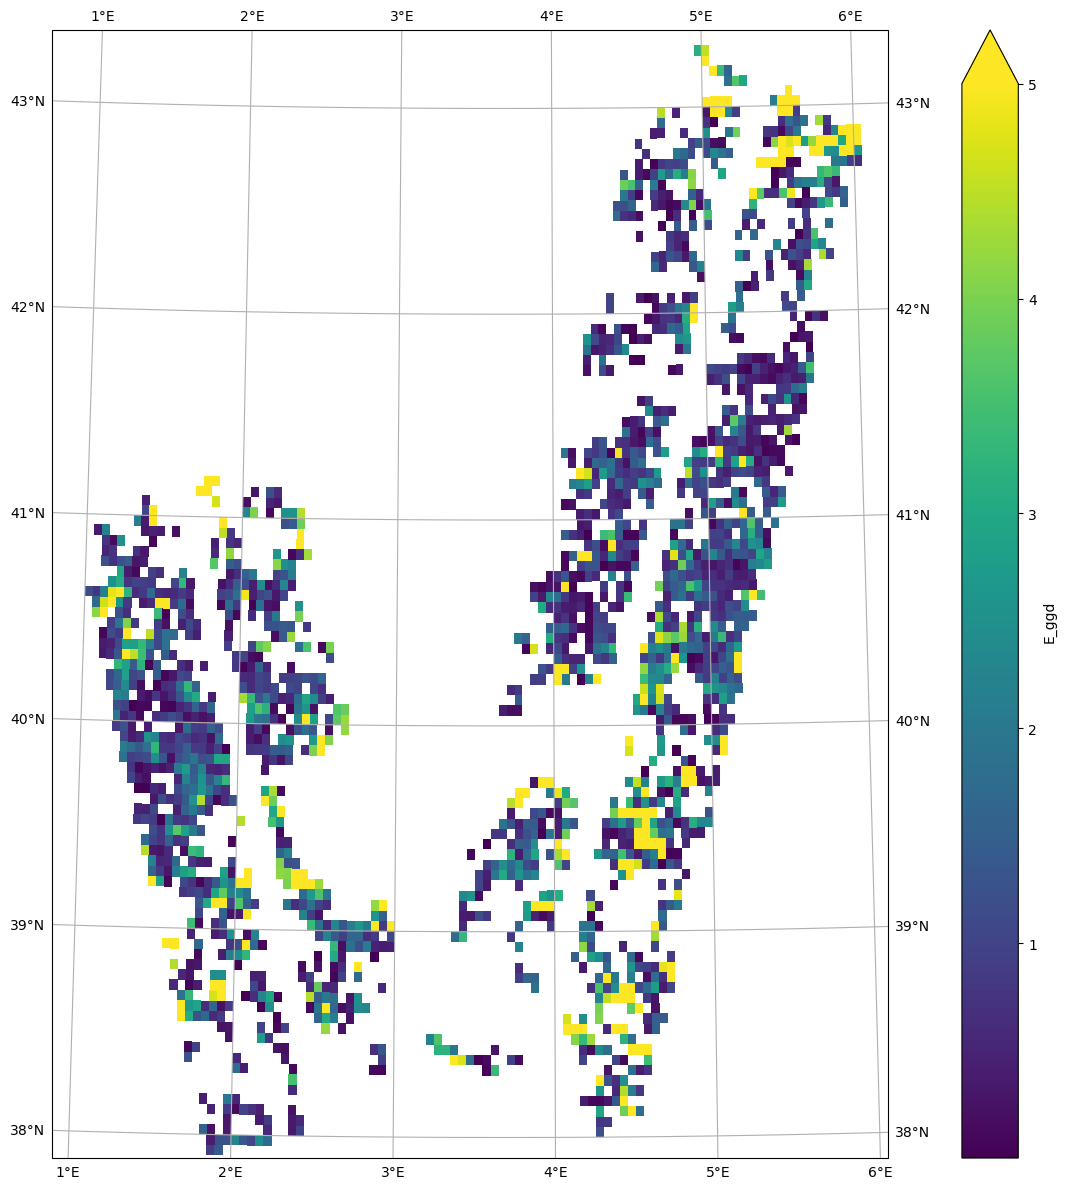

In [21]:
fig = plt.figure(figsize=(15,12))

ax = fig.add_subplot(111, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
ds.where(ds.E_ggd>0).E_ggd.plot(ax=ax, transform=crs, cmap = 'viridis', vmax=5)#, **xstyle[xn.replace('Xn_', '')])
#ax.add_feature(cfeature.LAND,)
gl = ax.gridlines(draw_labels=True,)
    #ds[xe].plot(ax=ax, label=xe)#, **xstyle[xe.replace('Xe_', '')])
    
fig.tight_layout()

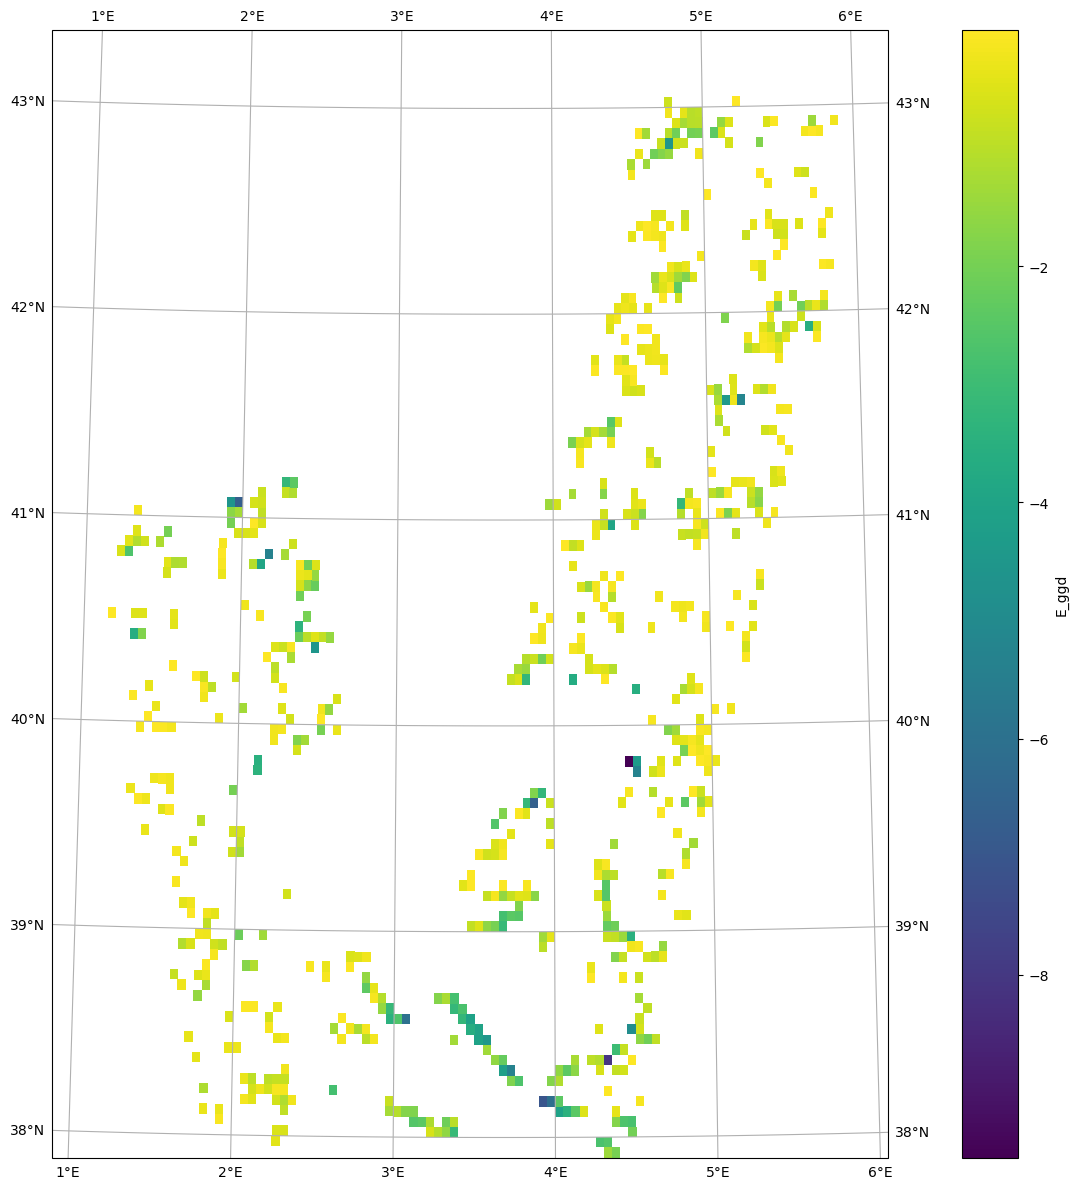

In [22]:
fig = plt.figure(figsize=(15,12))

ax = fig.add_subplot(111, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
ds.where(ds.E_ggd<0).E_ggd.plot(ax=ax, transform=crs, cmap = 'viridis')#, **xstyle[xn.replace('Xn_', '')])
#ax.add_feature(cfeature.LAND,)
gl = ax.gridlines(draw_labels=True,)
    #ds[xe].plot(ax=ax, label=xe)#, **xstyle[xe.replace('Xe_', '')])
    
fig.tight_layout()